# 🔧 NOTEBOOK 02 — Preprocessing & Sauvegarde des Données
## Objectifs
1. Charger et nettoyer le CSV
2. Lire, redimensionner et normaliser toutes les images → taille **96×96**
3. Encoder les labels
4. Créer les splits train / val / test
5. **Sauvegarder tout dans `data/processed/`** pour les notebooks suivants

> ⚠️ **Ce notebook doit être exécuté EN PREMIER avant tous les autres.**  
> Il génère les fichiers `.npy` et `.pkl` partagés par tous les notebooks CNN.

## 1. Imports & Configuration — SOURCE UNIQUE DE VÉRITÉ

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2, os, pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
#  ⚠️  PARAMÈTRES GLOBAUX — ne pas modifier après avoir exécuté
#       ce notebook (les autres notebooks lisent ce fichier)
# ─────────────────────────────────────────────────────────────
IMG_SIZE   = (96, 96)   # ← UNE SEULE TAILLE pour TOUS les modèles
TEST_SIZE  = 0.20
VAL_SIZE   = 0.15
SEED       = 42

# Chemins
CSV_PATH   = "../data/raw/flipkart.csv"
IMG_DIR    = "../data/raw/images/"
PROC_DIR   = "../data/processed/"
os.makedirs(PROC_DIR, exist_ok=True)

# Colonnes CSV (adapte si besoin)
CAT_COL    = "product_category_tree"
IMG_COL    = "image"

print("✅ Configuration :")
print(f"   IMG_SIZE  = {IMG_SIZE}")
print(f"   Test      = {int(TEST_SIZE*100)}%")
print(f"   Val       = {int(VAL_SIZE*100)}%")
print(f"   Train     ≈ {int((1-TEST_SIZE-VAL_SIZE)*100)}%")
print(f"   PROC_DIR  = {PROC_DIR}")


✅ Configuration :
   IMG_SIZE  = (96, 96)
   Test      = 20%
   Val       = 15%
   Train     ≈ 65%
   PROC_DIR  = ../data/processed/


## 2. Chargement & nettoyage du CSV

In [11]:
df = pd.read_csv(CSV_PATH)
df["category"] = (df[CAT_COL]
                  .str.extract(r'\["([^">>]+)')
                  .iloc[:, 0]
                  .str.strip())
df["img_path"] = df[IMG_COL].apply(lambda x: os.path.join(IMG_DIR, str(x)))
df["img_exists"] = df["img_path"].apply(os.path.exists)

df_clean = df[df["img_exists"] & df["category"].notna()].copy().reset_index(drop=True)

print(f"Produits initiaux  : {len(df)}")
print(f"Après nettoyage    : {len(df_clean)}")
print(f"Images manquantes  : {len(df) - len(df_clean)}")
print()
print("Distribution :")
print(df_clean["category"].value_counts().to_string())


Produits initiaux  : 1050
Après nettoyage    : 1050
Images manquantes  : 0

Distribution :
category
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150


## 3. Chargement & redimensionnement des images → 96×96

In [14]:

def load_image(path, size=IMG_SIZE):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    
    img = Image.open(path).convert("RGB")
    img = img.resize(size, Image.LANCZOS)
    
    return np.array(img, dtype=np.uint8)


# 🔍 TEST sur une image
sample_name = df_clean["img_path"].iloc[0]
sample_img  = load_image(sample_name)

print(f"Image test → shape={sample_img.shape} | dtype={sample_img.dtype}")
print(f"min={sample_img.min()} | max={sample_img.max()}")


Image test → shape=(96, 96, 3) | dtype=uint8
min=0 | max=255


In [16]:
# 🚀 CHARGEMENT DES IMAGES
import tqdm

X_all = []
valid_idx = []
errors = 0

for i, img_name in enumerate(tqdm.tqdm(df_clean["img_path"], desc="Chargement images")):
    try:
        img = load_image(img_name)
        X_all.append(img)
        valid_idx.append(i)
    except Exception:
        errors += 1

# Conversion en numpy array
X_all = np.array(X_all, dtype=np.uint8)

# DataFrame filtré (seulement images valides)
df_valid = df_clean.loc[valid_idx].reset_index(drop=True)

# 📊 Résumé
print("\n✅ Images chargées :", X_all.shape)
print("❌ Images ignorées :", errors)
print(f"💾 RAM ≈ {X_all.nbytes/1e6:.1f} MB")








































































































































































































































































































Chargement images: 100%|██████████| 1050/1050 [00:51<00:00, 20.35it/s]


✅ Images chargées : (1050, 96, 96, 3)
❌ Images ignorées : 0
💾 RAM ≈ 29.0 MB


## 4. Encodage des labels

In [17]:
le = LabelEncoder()
y_all = le.fit_transform(df_valid["category"].values)

print("Mapping label → entier :")
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y_all == i))
    print(f"  {i} → {cls:40} ({n} images)")

# Sauvegarder le LabelEncoder (utilisé dans Streamlit)
with open(os.path.join(PROC_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)
np.save(os.path.join(PROC_DIR, "class_names.npy"), le.classes_)
print("\n💾 label_encoder.pkl  sauvegardé")
print("💾 class_names.npy    sauvegardé")


Mapping label → entier :
  0 → Baby Care                                (150 images)
  1 → Beauty and Personal Care                 (150 images)
  2 → Computers                                (150 images)
  3 → Home Decor & Festive Needs               (150 images)
  4 → Home Furnishing                          (150 images)
  5 → Kitchen & Dining                         (150 images)
  6 → Watches                                  (150 images)

💾 label_encoder.pkl  sauvegardé
💾 class_names.npy    sauvegardé


## 5. Split train / val / test stratifié

In [18]:
# 1) Séparer le test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED
)
# 2) Séparer val du train
val_frac = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, stratify=y_tv, random_state=SEED
)

print(f"Train : {len(X_train):4d} images  ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"Val   : {len(X_val):4d} images  ({len(X_val)/len(X_all)*100:.0f}%)")
print(f"Test  : {len(X_test):4d} images  ({len(X_test)/len(X_all)*100:.0f}%)")


Train :  682 images  (65%)
Val   :  158 images  (15%)
Test  :  210 images  (20%)


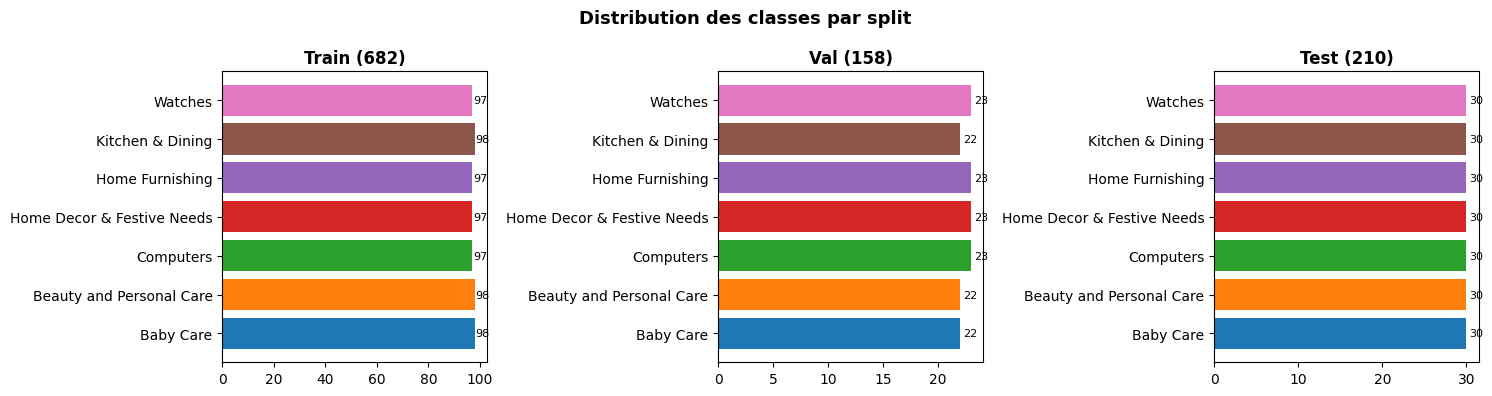

In [19]:
# Vérifier la distribution dans chaque split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_y, title) in zip(axes, [
    (y_train, f"Train ({len(y_train)})"),
    (y_val,   f"Val ({len(y_val)})"),
    (y_test,  f"Test ({len(y_test)})")
]):
    counts = [int(np.sum(split_y==i)) for i in range(len(le.classes_))]
    ax.barh(le.classes_, counts,
            color=plt.cm.tab10.colors[:len(le.classes_)])
    ax.set_title(title, fontweight="bold")
    for i, v in enumerate(counts):
        ax.text(v+0.3, i, str(v), va='center', fontsize=8)
plt.suptitle("Distribution des classes par split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/plots/02_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Normalisation et sauvegarde des .npy

In [20]:
# Normalisation [0,255] → [0.0, 1.0]
X_train_f = X_train.astype(np.float32) / 255.0
X_val_f   = X_val.astype(np.float32)   / 255.0
X_test_f  = X_test.astype(np.float32)  / 255.0

print(f"Après normalisation : min={X_train_f.min():.3f}  max={X_train_f.max():.3f}  dtype={X_train_f.dtype}")

# ─── Sauvegarde ─────────────────────────────────────────────
np.save(PROC_DIR + "X_train.npy", X_train_f)
np.save(PROC_DIR + "X_val.npy",   X_val_f)
np.save(PROC_DIR + "X_test.npy",  X_test_f)
np.save(PROC_DIR + "y_train.npy", y_train)
np.save(PROC_DIR + "y_val.npy",   y_val)
np.save(PROC_DIR + "y_test.npy",  y_test)

# Sauvegarder aussi la config pour que les notebooks suivants
# puissent vérifier qu'ils utilisent les bons paramètres
config = {
    "IMG_SIZE":  IMG_SIZE,
    "N_CLASSES": len(le.classes_),
    "N_TRAIN":   len(X_train),
    "N_VAL":     len(X_val),
    "N_TEST":    len(X_test),
    "SEED":      SEED,
}
with open(PROC_DIR + "config.pkl", "wb") as f:
    pickle.dump(config, f)

print()
print("💾 Fichiers sauvegardés dans data/processed/ :")
for fname in sorted(os.listdir(PROC_DIR)):
    size = os.path.getsize(PROC_DIR + fname) / 1e6
    print(f"   {fname:30} {size:.1f} MB")


Après normalisation : min=0.000  max=1.000  dtype=float32

💾 Fichiers sauvegardés dans data/processed/ :
   X_test.npy                     23.2 MB
   X_train.npy                    75.4 MB
   X_val.npy                      17.5 MB
   class_names.npy                0.0 MB
   config.pkl                     0.0 MB
   label_encoder.pkl              0.0 MB
   y_test.npy                     0.0 MB
   y_train.npy                    0.0 MB
   y_val.npy                      0.0 MB


## 7. Visualisation d'exemples normalisés

Exception ignored in: <function tqdm.__del__ at 0x0000011848EAC360>
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


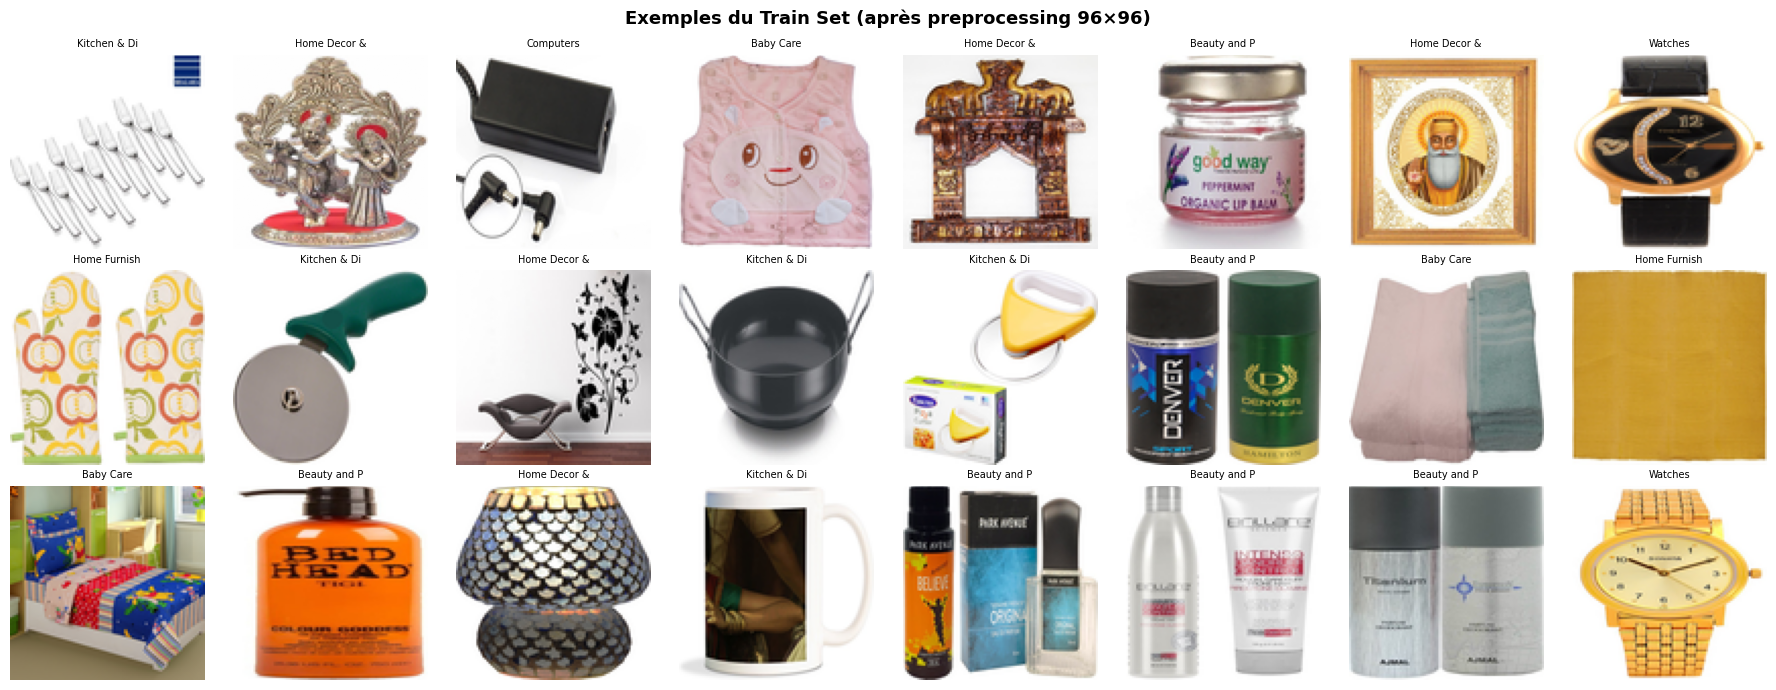


  ✅ NOTEBOOK 02 TERMINÉ

  Fichiers générés :
    data/processed/X_train.npy  ← images train normalisées
    data/processed/X_val.npy    ← images val
    data/processed/X_test.npy   ← images test
    data/processed/y_train.npy  ← labels entiers train
    data/processed/y_val.npy    ← labels entiers val
    data/processed/y_test.npy   ← labels entiers test
    data/processed/label_encoder.pkl ← pour Streamlit
    data/processed/class_names.npy   ← noms des classes
    data/processed/config.pkl        ← paramètres partagés

  → Exécuter ensuite : 03_cnn_scratch.ipynb


In [21]:
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
fig.suptitle("Exemples du Train Set (après preprocessing 96×96)", fontsize=13, fontweight="bold")
idxs = np.random.choice(len(X_train_f), 24, replace=False)
for ax, idx in zip(axes.flatten(), idxs):
    ax.imshow(X_train_f[idx])
    ax.set_title(le.classes_[y_train[idx]][:12], fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../outputs/plots/02_train_samples.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("="*55)
print("  ✅ NOTEBOOK 02 TERMINÉ")
print("="*55)
print()
print("  Fichiers générés :")
print("    data/processed/X_train.npy  ← images train normalisées")
print("    data/processed/X_val.npy    ← images val")
print("    data/processed/X_test.npy   ← images test")
print("    data/processed/y_train.npy  ← labels entiers train")
print("    data/processed/y_val.npy    ← labels entiers val")
print("    data/processed/y_test.npy   ← labels entiers test")
print("    data/processed/label_encoder.pkl ← pour Streamlit")
print("    data/processed/class_names.npy   ← noms des classes")
print("    data/processed/config.pkl        ← paramètres partagés")
print()
print("  → Exécuter ensuite : 03_cnn_scratch.ipynb")
